# Rheology of Newtonian & Non-Newtonian Materials

Apply the `RheologyPipeline` (from `rheology_pipeline_core.py`) to the five datasets in this folder and visualise the rheology of each sample **step-by-step**:

| # | Dataset       | Material family            | Expected behaviour                  |
|---|---------------|----------------------------|-------------------------------------|
| 1 | `silicone.csv`| Silicone oils (calibration)| Newtonian (single-RPM per cell)     |
| 2 | `PEG.csv`     | Poly-ethylene glycol       | Newtonian → mildly shear-thinning   |
| 3 | `sepineo.csv` | Sepineo (acrylate gel)     | Shear-thinning                      |
| 4 | `solagum.csv` | Solagum (polysaccharide)   | Strongly shear-thinning             |
| 5 | `carbopol.csv`| Carbopol 980 (yield-stress)| Shear-thinning (yield-pseudoplastic)|

The pipeline:
1. Fits each drag profile $D(h)=A/(h+h_c)+B$ to extract the amplitude $A$.
2. Converts $A \to \mu_\text{app}$ via the silicone calibration $A=k\,\mu^p$.
3. If multiple RPMs are present per cell, fits a power-law $A(\dot\gamma)=A_0\,\dot\gamma^{\,n-1}$ to classify the flow regime.

## Step 1 — Imports, paths & plotting style

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── Make the repo importable ─────────────────────────────────────────────────
REPO = Path(r"C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from rheology_pipeline_core import RheologyPipeline, fit_drag_profile

# ── Dataset paths ────────────────────────────────────────────────────────────
DATA_DIR  = REPO / "Rheology_Newtonian_Non_Newtonian_Material"
CALIB_CSV = REPO / "results" / "Auto-runs" / "height_normalized.csv"

SAMPLES = {
    "silicone": DATA_DIR / "silicone.csv",
    "PEG"     : DATA_DIR / "PEG.csv",
    "sepineo" : DATA_DIR / "sepineo.csv",
    "solagum" : DATA_DIR / "solagum.csv",
    "carbopol": DATA_DIR / "carbopol.csv",
}

# ── Google plotting style ────────────────────────────────────────────────────
mpl.rcParams["font.family"] = "Arial"
GOOGLE_COLORS = ["#4285F4", "#EA4335", "#FBBC05", "#34A853", "#FF6D00", "#46BDC6"]
GOOGLE_CMAP   = LinearSegmentedColormap.from_list(
    "google", [GOOGLE_COLORS[0], GOOGLE_COLORS[2], GOOGLE_COLORS[1]]
)
BORDER, FS_LABEL, FS_TICK, FS_LEGEND = 1.5, 16, 12, 12

def _gs(ax):
    ax.grid(False)
    ax.tick_params(labelsize=FS_TICK)
    for sp in ax.spines.values():
        sp.set_linewidth(BORDER)

def _cb(mappable, ax, label):
    cb = plt.colorbar(mappable, ax=ax)
    cb.set_label(label, fontsize=FS_LEGEND)
    cb.ax.tick_params(labelsize=FS_TICK - 2)
    cb.outline.set_linewidth(BORDER)
    return cb

print("Repo            :", REPO)
print("Calibration CSV :", CALIB_CSV.relative_to(REPO), "(exists:", CALIB_CSV.exists(), ")")
print("Sample CSVs     :")
for k, p in SAMPLES.items():
    print(f"  {k:<9s} → {p.relative_to(REPO)}  (exists: {p.exists()})")

Repo            : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry
Calibration CSV : results\Auto-runs\height_normalized.csv (exists: True )
Sample CSVs     :
  silicone  → Rheology_Newtonian_Non_Newtonian_Material\silicone.csv  (exists: True)
  PEG       → Rheology_Newtonian_Non_Newtonian_Material\PEG.csv  (exists: True)
  sepineo   → Rheology_Newtonian_Non_Newtonian_Material\sepineo.csv  (exists: True)
  solagum   → Rheology_Newtonian_Non_Newtonian_Material\solagum.csv  (exists: True)
  carbopol  → Rheology_Newtonian_Non_Newtonian_Material\carbopol.csv  (exists: True)


## Step 2 — Load the silicone calibration

Load the universal cone-plate offset $h_c$ and the silicone calibration $A = k\,\mu^p$ from `results/Auto-runs/height_normalized.csv`. All five samples are analysed with the **same** calibration so their viscosities are directly comparable.

In [2]:
pipeline = RheologyPipeline()
cal = pipeline.load_silicone_calibration(CALIB_CSV)

print("=== Universal calibration ===")
for k, v in cal.items():
    print(f"  {k:25s}: {v:.6g}")

print()
print(f"h_c (universal) = {pipeline.H_C_UNIVERSAL:.4f} mm")
print(f"k               = {pipeline.SILICONE_K:.4e}")
print(f"p               = {pipeline.SILICONE_P:.4f}")
print(f"Calibrated?     = {pipeline.is_calibrated}")

=== Universal calibration ===
  h_c                      : 0.232399
  k                        : 5.75966e-09
  p                        : 1.9837
  R2_calibration           : 0.988727
  n_silicones              : 23

h_c (universal) = 0.2324 mm
k               = 5.7597e-09
p               = 1.9837
Calibrated?     = True


## Step 3 — Generic helper: load, clean and analyse a sample CSV

Every dataset follows the same row schema (`Cell_Label, Z_Height_mm, RPM, Torque_%`). The helpers below:

1. **`load_sample(path)`** — read CSV, drop repeated headers / NaNs / `Torque_%==0` rows, coerce numeric columns and **re-zero the height per cell** ($h = h_\text{raw} - h_\text{raw,min}$, as our repo convention dictates).
2. **`parse_true_mu(label)`** — extract a reference viscosity from the cell label whenever it is encoded (e.g. `l60000_b_a69080` → 69 080 cP, `980carb0.3%_49810` → 49 810 cP).
3. **`analyse_cell(df_cell, pipeline)`** — auto-detect single vs multi-RPM, call `pipeline.predict_rheology(...)`, and additionally extract per-RPM amplitudes / apparent viscosities for plotting the flow curve.

In [6]:
# ── Generic loader ───────────────────────────────────────────────────────────
NUM_COLS = ["Z_Height_mm", "RPM", "Torque_%", "Rotational_Drag"]

def load_sample(path: Path) -> pd.DataFrame:
    """Read a sample CSV; clean it; re-zero height; collapse duplicate samples."""
    df = pd.read_csv(path, encoding="latin-1", low_memory=False)

    # Some CSVs contain accidentally-concatenated header rows.
    df = df[df["RPM"].astype(str).str.strip() != "RPM"].copy()

    for c in NUM_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=NUM_COLS)
    df = df[df["Torque_%"] > 0]            # ignore "insufficient_data" rows
    df = df[df["RPM"] > 0]

    # Re-zero height *per cell* — convention from the repo notes.
    df["h_mm"] = df.groupby("Cell_Label")["Z_Height_mm"].transform(
        lambda s: s - s.min()
    )

    # Round RPM to a stable key (avoids float-precision multi-grouping)
    df["RPM_key"] = df["RPM"].round(4)

    # Collapse duplicate samples at the same (cell, RPM, h_mm) by mean Torque.
    df = (df.groupby(["Cell_Label", "RPM_key", "h_mm"], as_index=False)
            .agg(Z_Height_mm=("Z_Height_mm", "mean"),
                 RPM        =("RPM",         "mean"),
                 **{"Torque_%": ("Torque_%", "mean")},
                 Rotational_Drag=("Rotational_Drag", "mean")))
    return df.reset_index(drop=True)

## Step 4 — Sample 1 · Silicone oils (Newtonian reference)

Each silicone cell was measured at a **single RPM**, so the pipeline returns a Newtonian viscosity per cell. The label encodes the rheometer reference (e.g. `l60000_b_a69080` → 69 080 cP). We expect the predicted $\mu_\text{app}$ to track the label very closely — this is essentially the calibration self-check. We plot a handful of representative cells across the full viscosity range.


SILICONE  (silicone.csv)
  rows : 1,124    cells : 37    plotting : 6


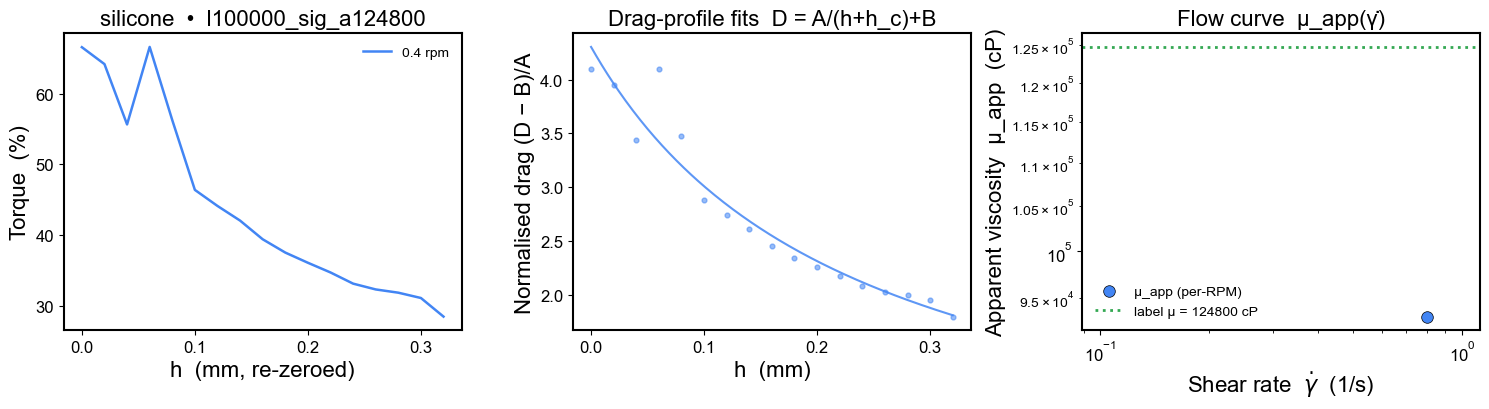

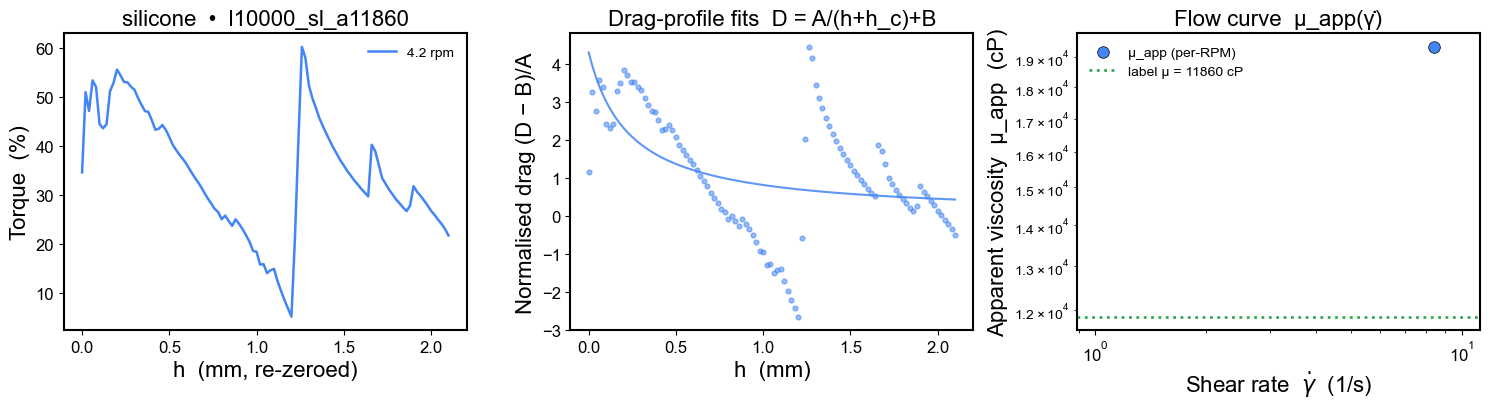

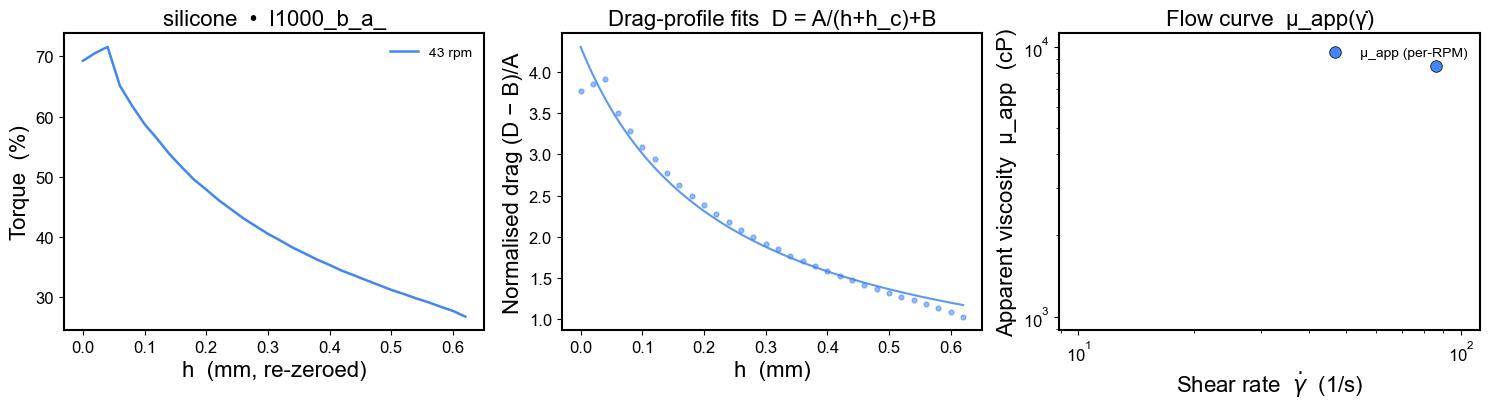

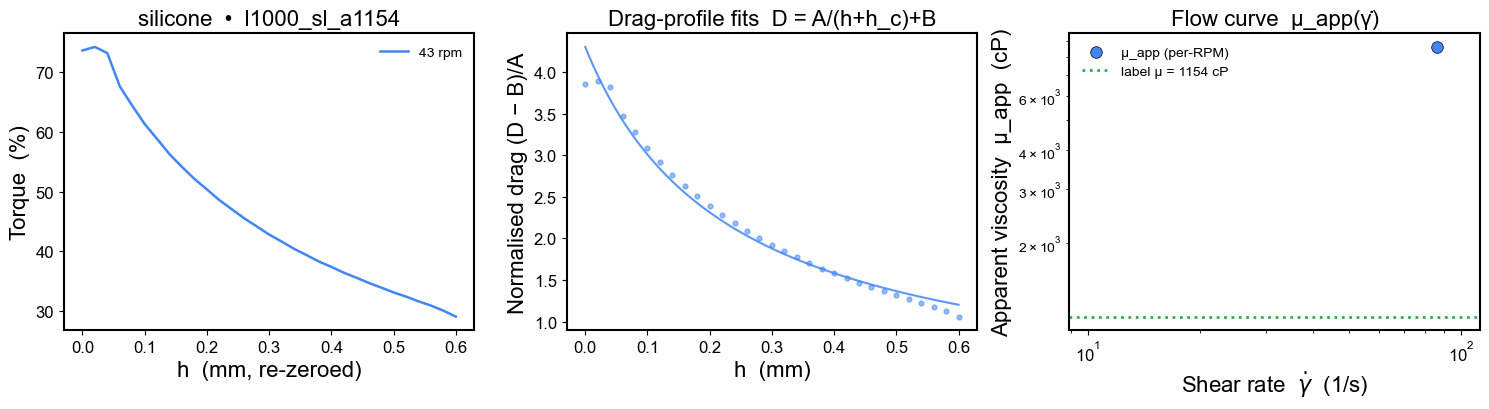

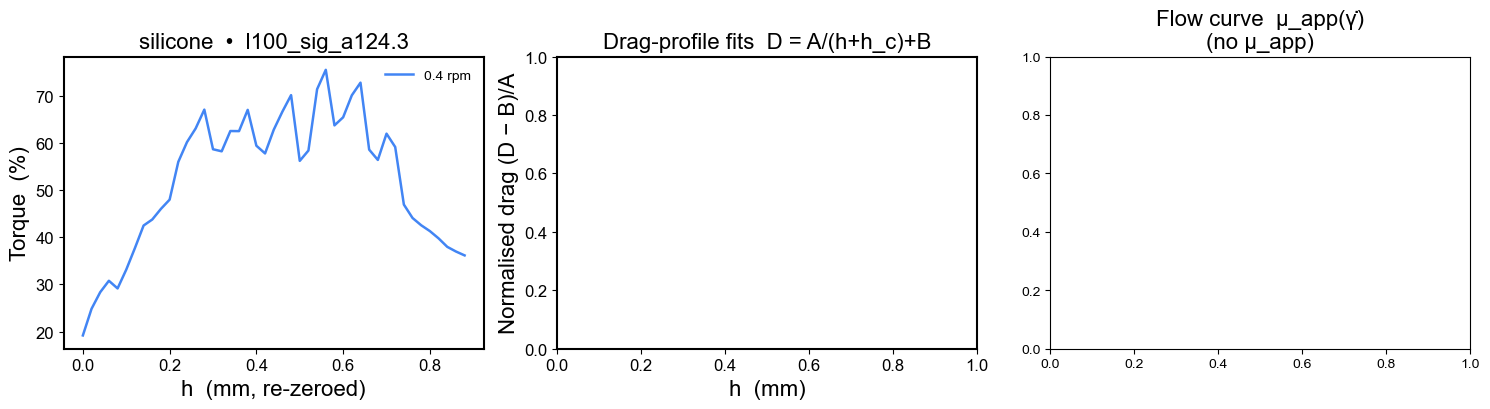

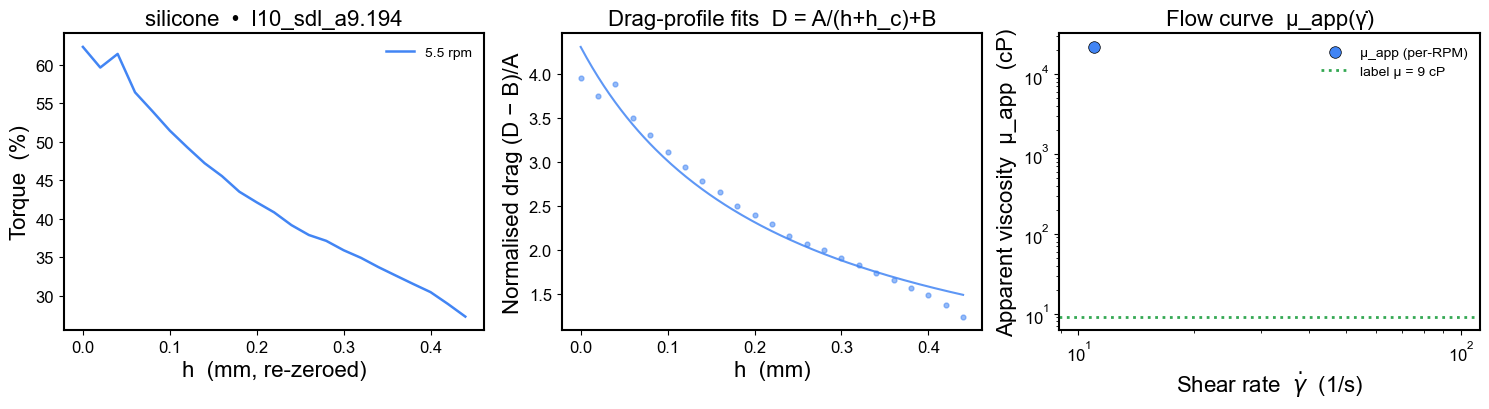


--- Per-cell summary ---
              label  true_mu_cP  n_rpms                   regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
l100000_sig_a124800    1.25e+05       1                Newtonian      1   9.31e+04         0.931          NaN
   l10000_sl_a11860    1.19e+04       1                Newtonian      1   1.94e+04          0.27          NaN
         l1000_b_a_         NaN       1                Newtonian      1   8.52e+03         0.979          NaN
     l1000_sl_a1154    1.15e+03       1                Newtonian      1   8.64e+03         0.984          NaN
    l100_sig_a124.3         124       1 Error: invalid amplitude    NaN        NaN         0.348          NaN
     l10_sdl_a9.194        9.19       1                Newtonian      1   2.19e+04         0.974          NaN
     l10_sil_a11.86        11.9       1                Newtonian      1   2.29e+04         0.973          NaN
     l12.5_b_a14.57        14.6       1                Newtonian      1    2.9e+04         0.9

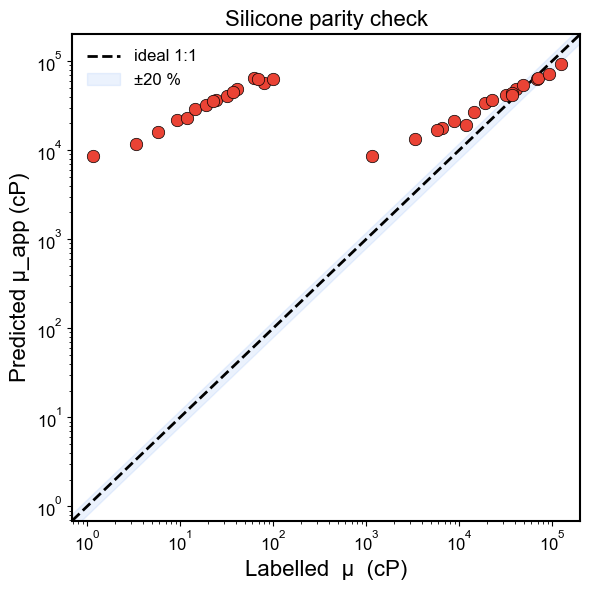

  median |error| = 471.9 %   within ±20% : 15 %   N = 34


In [10]:
# silicone has 37 cells → plot only a handful of representative ones,
# but still tabulate the full set.
summary_silicone = analyse_sample("silicone", SAMPLES["silicone"], pipeline,
                                  max_cells_to_plot=6)

# ── Parity plot: predicted vs labelled viscosity ─────────────────────────────
sil = summary_silicone.dropna(subset=["true_mu_cP", "mu_app_cP"]).copy()
sil = sil[(sil["true_mu_cP"] > 0) & (sil["mu_app_cP"] > 0)]

if not sil.empty:
    fig, ax = plt.subplots(figsize=(6, 6))
    lim = [sil["true_mu_cP"].min() * 0.6, sil["true_mu_cP"].max() * 1.6]
    ax.plot(lim, lim, "k--", lw=2, label="ideal 1:1")
    ax.fill_between(lim, [v*0.8 for v in lim], [v*1.2 for v in lim],
                    alpha=0.10, color=GOOGLE_COLORS[0], label="±20 %")
    ax.scatter(sil["true_mu_cP"], sil["mu_app_cP"],
               s=80, color=GOOGLE_COLORS[1], edgecolors="k",
               linewidths=0.5, zorder=3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim);     ax.set_ylim(lim)
    ax.set_xlabel("Labelled  μ  (cP)",  fontsize=FS_LABEL)
    ax.set_ylabel("Predicted μ_app (cP)", fontsize=FS_LABEL)
    ax.set_title("Silicone parity check", fontsize=FS_LABEL)
    ax.legend(fontsize=FS_LEGEND, frameon=False)
    _gs(ax)
    plt.tight_layout(); plt.show()

    err = (sil["mu_app_cP"] - sil["true_mu_cP"]) / sil["true_mu_cP"] * 100
    print(f"  median |error| = {err.abs().median():.1f} %"
          f"   within ±20% : {(err.abs() <= 20).mean()*100:.0f} %"
          f"   N = {len(sil)}")

## Step 5 — Sample 2 · PEG (poly-ethylene glycol)

PEG solutions are essentially Newtonian at low concentrations and develop mild shear-thinning at higher MW/concentration. Every PEG cell was probed at **multiple RPMs**, so the pipeline now fits a power-law $A(\dot\gamma)=A_0\,\dot\gamma^{n-1}$ and classifies each formulation.


PEG  (PEG.csv)
  rows : 4,462    cells : 5    plotting : 5


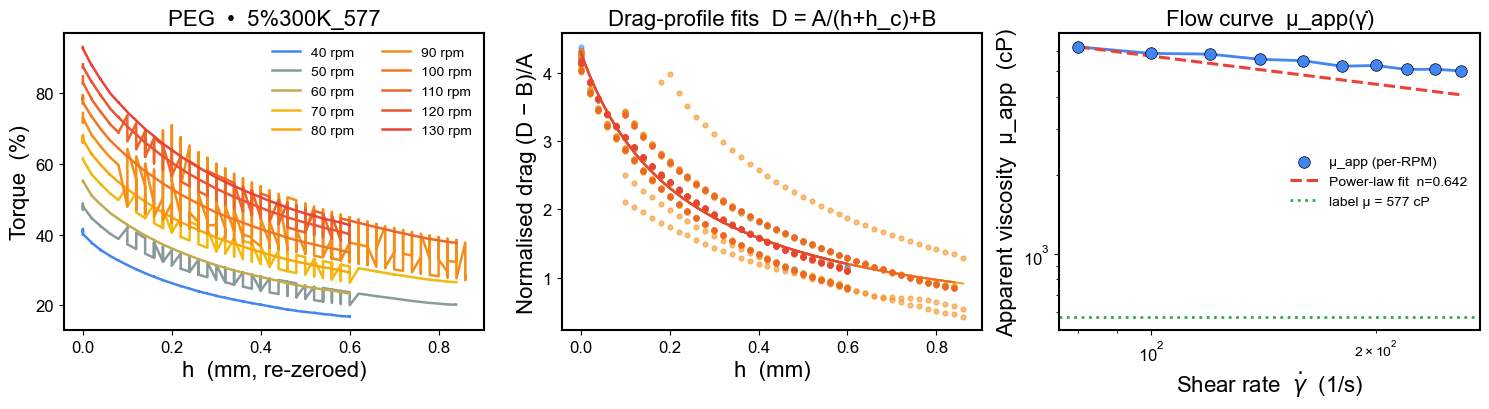

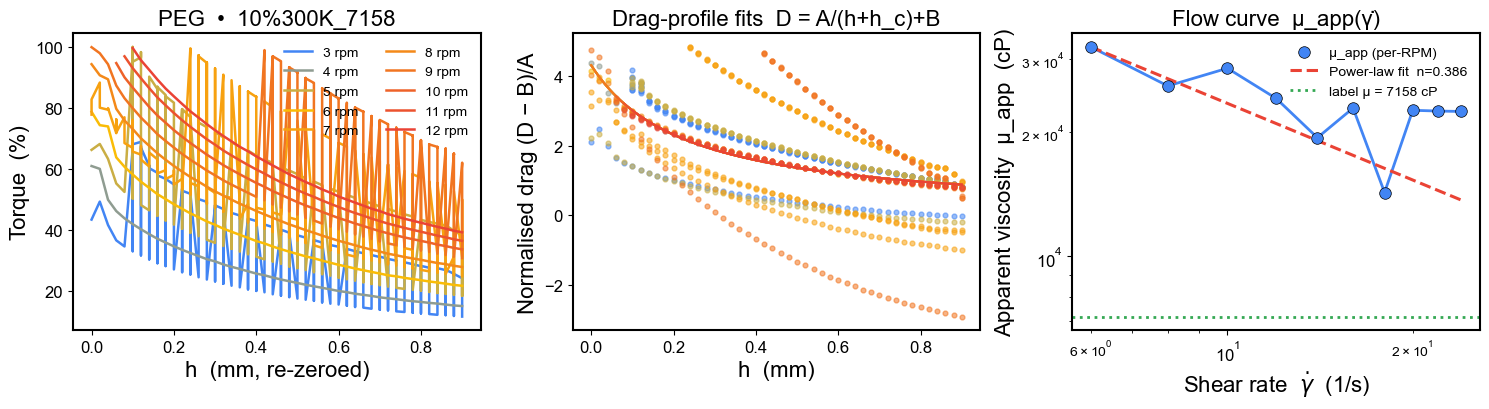

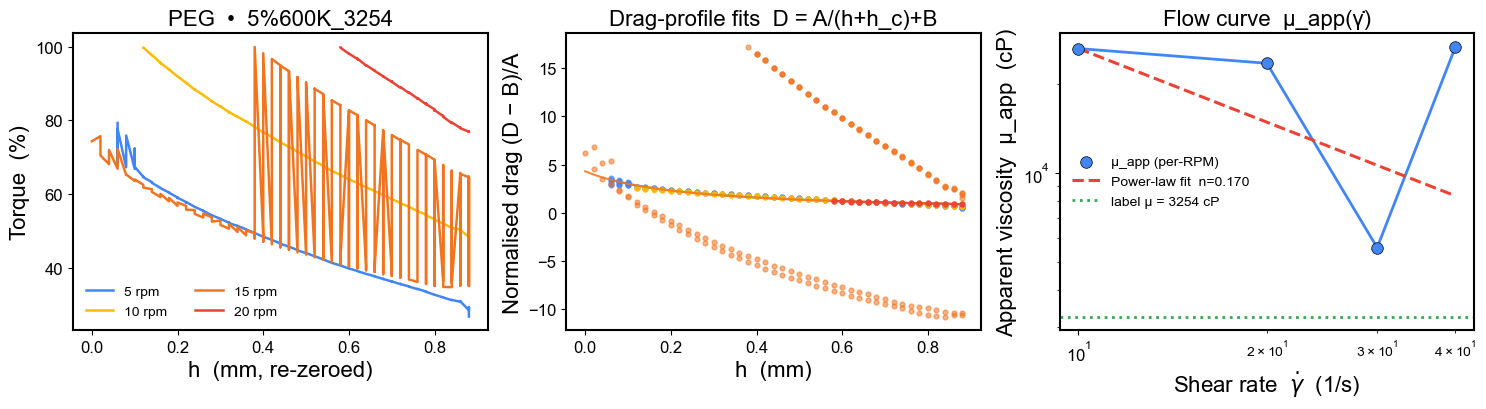

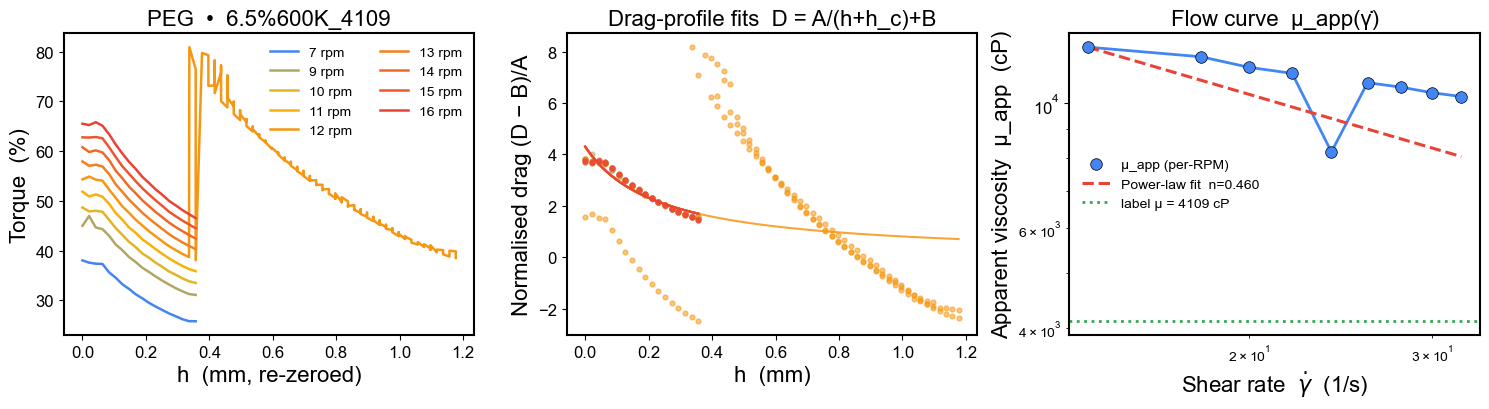

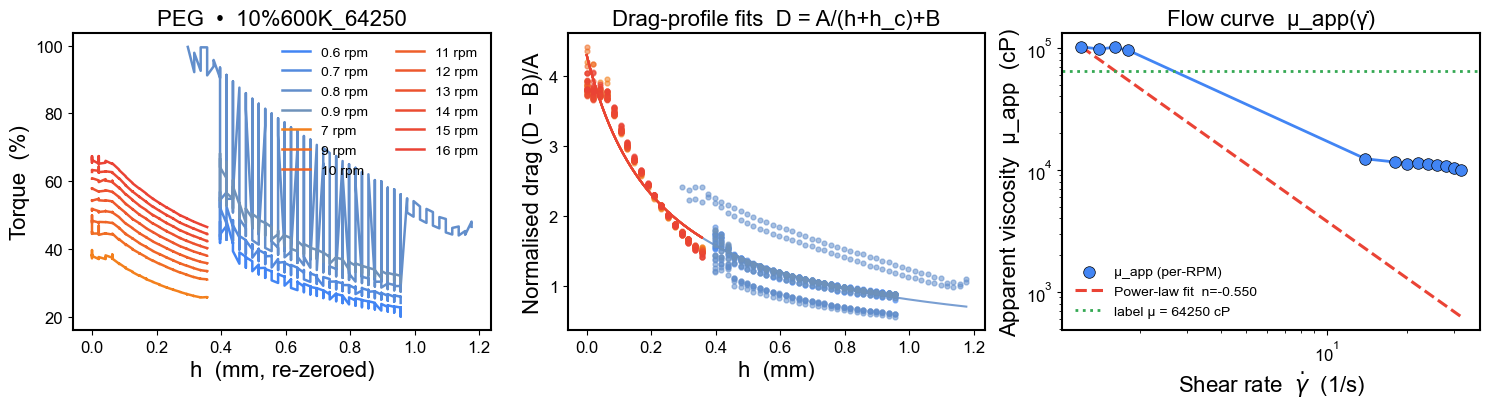


--- Per-cell summary ---
        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
   5%300K_577         577      10 shear-thinning  0.642    6.2e+03          0.95        0.977
 10%300K_7158    7.16e+03      10 shear-thinning  0.386    3.2e+04          0.72        0.416
  5%600K_3254    3.25e+03       4 shear-thinning   0.17   2.64e+04         0.728        0.109
6.5%600K_4109    4.11e+03       9 shear-thinning   0.46   1.26e+04         0.835        0.341
10%600K_64250    6.42e+04      13 shear-thinning  -0.55   1.02e+05         0.886        0.983


In [5]:
summary_PEG = analyse_sample("PEG", SAMPLES["PEG"], pipeline)

## Step 6 — Sample 3 · Sepineo (cross-linked acrylate gel)

Sepineo is a classic shear-thinning thickener used in skincare. Expect $n < 1$ and $\mu_\text{app}$ that decreases with shear rate.


SEPINEO  (sepineo.csv)
  rows : 847    cells : 3    plotting : 3


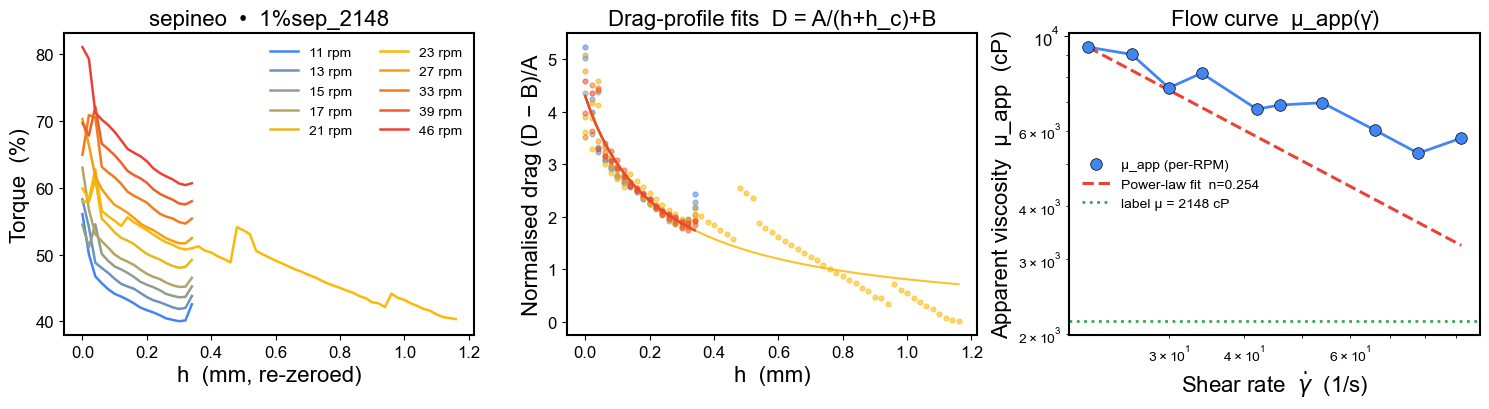

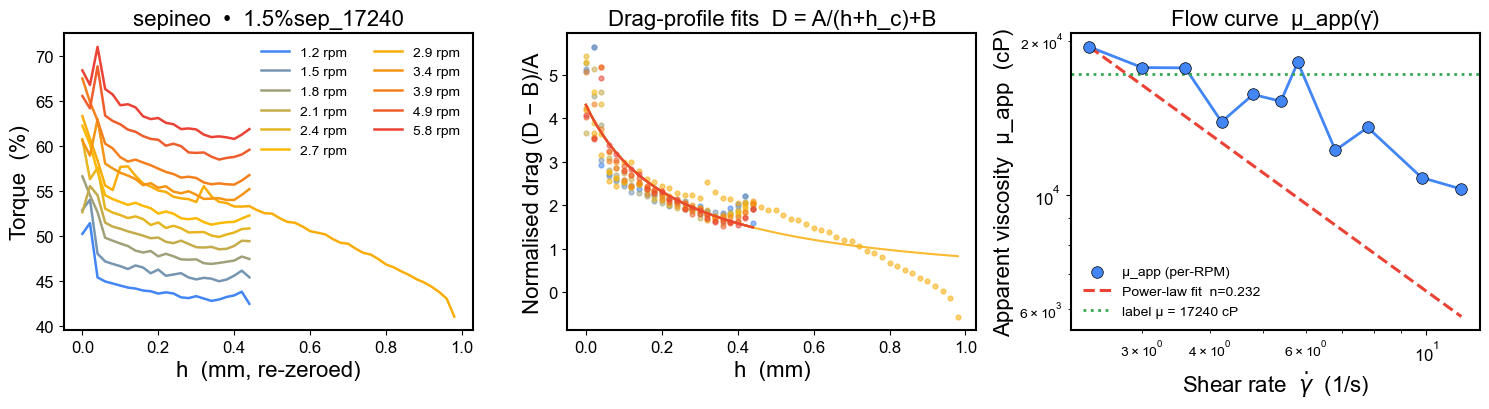

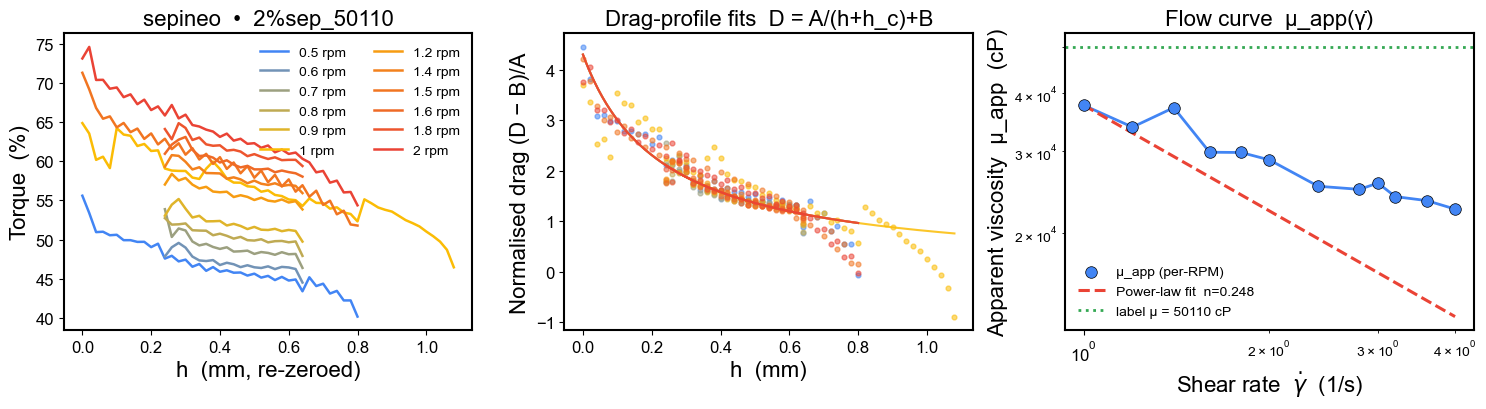


--- Per-cell summary ---
        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
   1%sep_2148    2.15e+03      10 shear-thinning  0.254    9.4e+03         0.893        0.906
1.5%sep_17240    1.72e+04      11 shear-thinning  0.232   1.94e+04         0.802        0.768
  2%sep_50110    5.01e+04      12 shear-thinning  0.248   3.76e+04         0.849        0.929


In [7]:
summary_sepineo = analyse_sample("sepineo", SAMPLES["sepineo"], pipeline)

## Step 7 — Sample 4 · Solagum (polysaccharide gum)

Solagum gels strongly with concentration; expect a steep drop of $\mu_\text{app}$ versus $\dot\gamma$ ($n \ll 1$).


SOLAGUM  (solagum.csv)
  rows : 945    cells : 3    plotting : 3


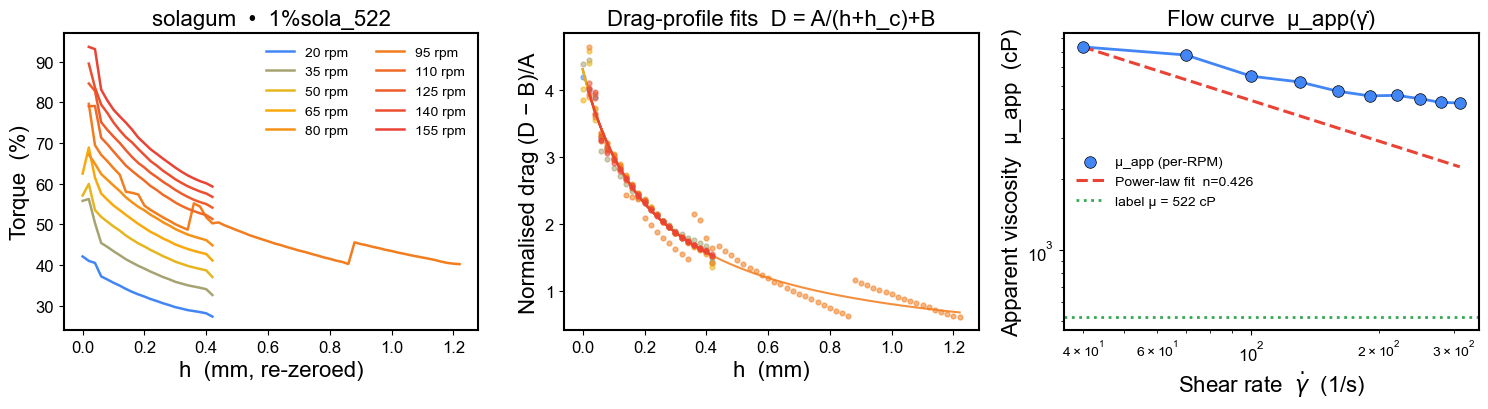

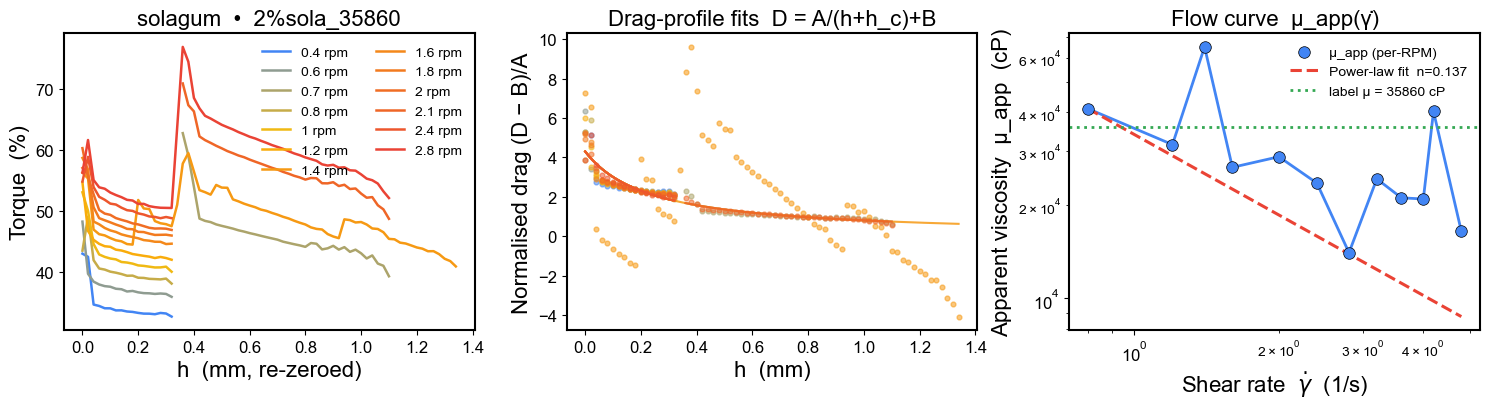

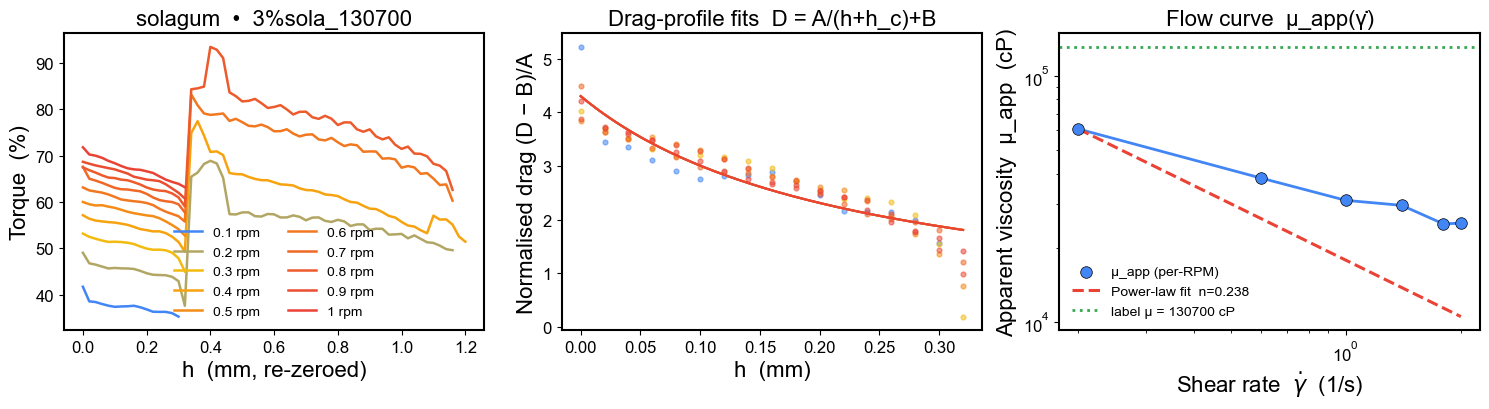


--- Per-cell summary ---
        label  true_mu_cP  n_rpms         regime  n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
   1%sola_522         522      10 shear-thinning  0.426   7.33e+03          0.98        0.966
 2%sola_35860    3.59e+04      13 shear-thinning  0.137    4.1e+04         0.644        0.339
3%sola_130700    1.31e+05      10 shear-thinning  0.238   6.06e+04         0.565         0.99


In [8]:
summary_solagum = analyse_sample("solagum", SAMPLES["solagum"], pipeline)

## Step 8 — Sample 5 · Carbopol 980 (yield-pseudoplastic)

Carbopol exhibits a yield stress plus strong shear-thinning. The power-law fit captures the high-shear branch ($n \ll 1$); the yield contribution shows up as the up-turn of $\mu_\text{app}$ at the lowest shear rates.


CARBOPOL  (carbopol.csv)
  rows : 296    cells : 2    plotting : 2


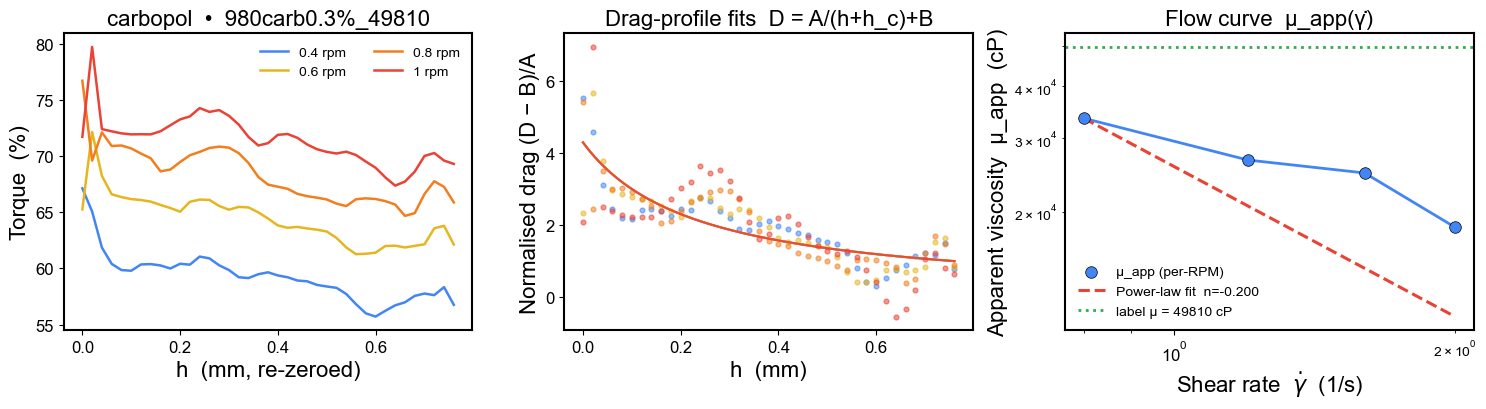

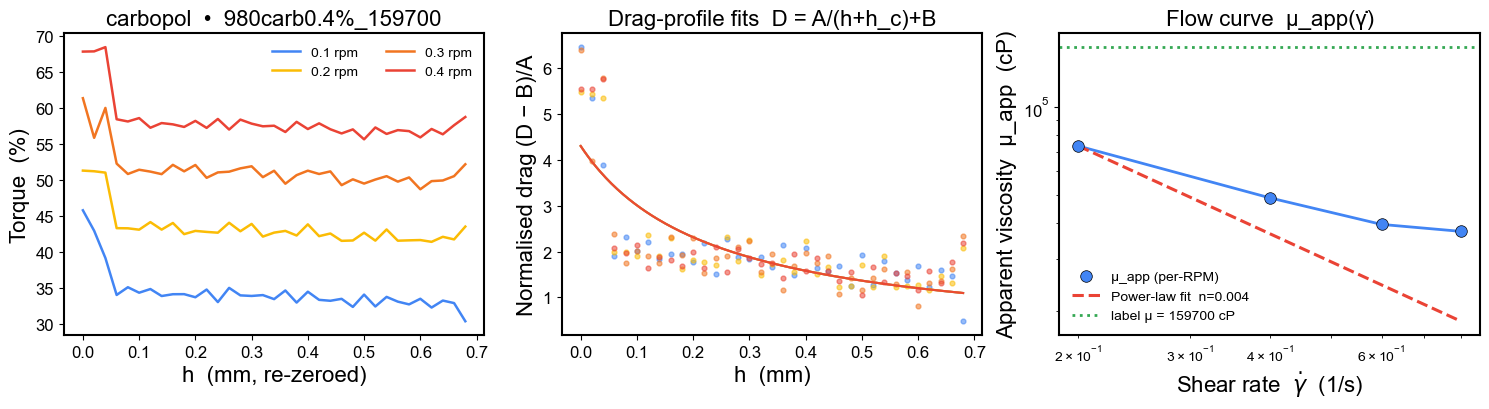


--- Per-cell summary ---
             label  true_mu_cP  n_rpms         regime   n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
 980carb0.3%_49810    4.98e+04       4 shear-thinning    -0.2   3.35e+04         0.646        0.922
980carb0.4%_159700     1.6e+05       4 shear-thinning 0.00449   7.33e+04         0.602        0.979


In [9]:
summary_carbopol = analyse_sample("carbopol", SAMPLES["carbopol"], pipeline)

## Step 9 — Cross-sample summary

A single tidy table of every cell across all five materials, followed by a master flow-curve plot that overlays one representative cell per non-Newtonian sample so the rheology fingerprints can be compared at a glance.

Total cells analysed: 50

  sample               label  true_mu_cP  n_rpms                   regime   n_idx  mu_app_cP  R2_drag_mean  R2_powerlaw
silicone l100000_sig_a124800    1.25e+05       1                Newtonian       1   9.31e+04         0.931          NaN
silicone    l10000_sl_a11860    1.19e+04       1                Newtonian       1   1.94e+04          0.27          NaN
silicone          l1000_b_a_         NaN       1                Newtonian       1   8.52e+03         0.979          NaN
silicone      l1000_sl_a1154    1.15e+03       1                Newtonian       1   8.64e+03         0.984          NaN
silicone     l100_sig_a124.3         124       1 Error: invalid amplitude     NaN        NaN         0.348          NaN
silicone      l10_sdl_a9.194        9.19       1                Newtonian       1   2.19e+04         0.974          NaN
silicone      l10_sil_a11.86        11.9       1                Newtonian       1   2.29e+04         0.973          NaN
silicone      

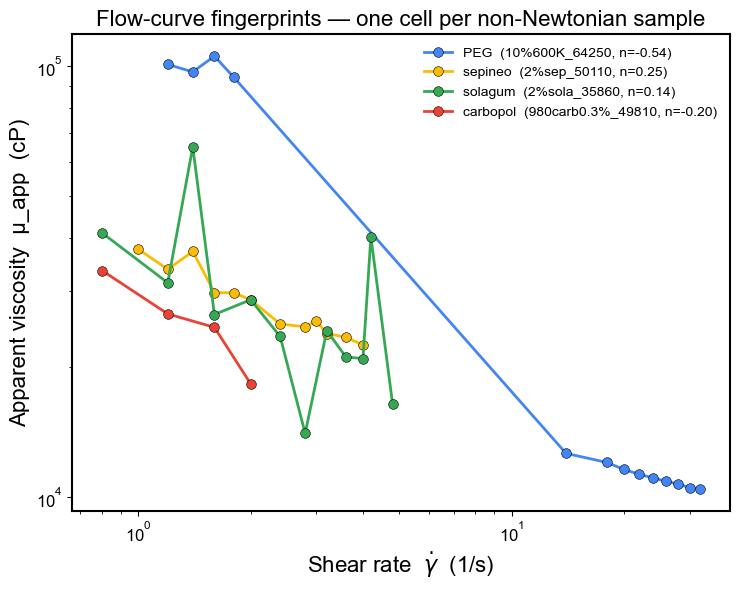


Summary written → Rheology_Newtonian_Non_Newtonian_Material\rheology_pipeline_summary.csv


In [11]:
summary_all = pd.concat(
    [summary_silicone, summary_PEG, summary_sepineo, summary_solagum, summary_carbopol],
    ignore_index=True,
)

print(f"Total cells analysed: {len(summary_all)}")
print()

with pd.option_context("display.float_format", "{:,.3g}".format,
                       "display.max_rows", 200,
                       "display.width", 140):
    cols = ["sample", "label", "true_mu_cP", "n_rpms",
            "regime", "n_idx", "mu_app_cP", "R2_drag_mean", "R2_powerlaw"]
    print(summary_all[cols].to_string(index=False))

# ── Master flow-curve comparison: one representative cell per non-Newtonian sample
def _pick_cell(df_all, sample):
    sub = df_all[df_all["Cell_Label"].isin(
        summary_all.loc[summary_all["sample"] == sample, "label"]
    )]
    # representative = cell with the most RPM points
    counts = (sub.groupby("Cell_Label")["RPM"].nunique()
              .sort_values(ascending=False))
    return counts.index[0] if len(counts) else None

fig, ax = plt.subplots(figsize=(7.5, 6))
colors = {"PEG"     : GOOGLE_COLORS[0],
          "sepineo" : GOOGLE_COLORS[2],
          "solagum" : GOOGLE_COLORS[3],
          "carbopol": GOOGLE_COLORS[1]}

for sample in ["PEG", "sepineo", "solagum", "carbopol"]:
    df = load_sample(SAMPLES[sample])
    cl = _pick_cell(df, sample)
    if cl is None:
        continue
    an = analyse_cell(df[df["Cell_Label"] == cl], pipeline)
    pr = an["per_rpm"].dropna(subset=["mu_app_cP"])
    pr = pr[pr["mu_app_cP"] > 0]
    if pr.empty:
        continue
    label_txt = f"{sample}  ({cl}, n={an['result'].get('n', float('nan')):.2f})"
    ax.plot(pr["gamma_dot_1_s"], pr["mu_app_cP"],
            "-o", color=colors[sample], lw=2.0, ms=7,
            markeredgecolor="k", markeredgewidth=0.4, label=label_txt)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"Shear rate  $\dot\gamma$  (1/s)", fontsize=FS_LABEL)
ax.set_ylabel("Apparent viscosity  μ_app  (cP)",   fontsize=FS_LABEL)
ax.set_title("Flow-curve fingerprints — one cell per non-Newtonian sample",
             fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND - 2, frameon=False, loc="best")
_gs(ax)
plt.tight_layout(); plt.show()

# ── Save the unified summary CSV next to the data ────────────────────────────
out_csv = DATA_DIR / "rheology_pipeline_summary.csv"
summary_all.to_csv(out_csv, index=False)
print(f"\nSummary written → {out_csv.relative_to(REPO)}")